# PM10 Next-Day Forecasting (Krakow)
#### With weather data, model trained on actual data but some weather api would be used to get the next day forecast

In [62]:
import os
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tcn import TCN

import optuna
from optuna.integration import TFKerasPruningCallback

## 0. Configuration

In [50]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

TIMEZONE = "Europe/Warsaw"
START_DATE = "2017-02-17"
END_DATE = "2020-10-10"
TEST_DAYS = 90

ROLL_WINDOWS = [3, 7, 14]
PM10_LAGS = [1, 2, 3, 7, 14]
SEQ_LEN = 14

DL_EPOCHS = 50
BATCH_SIZE = 32
PATIENCE = 8
WALK_SPLITS = 3

OPTUNA_TRIALS = 50
LOG_DIR = "tb_logs"

## 1. Load PM10 data

In [51]:
MEASUREMENTS_CSV = "measurements.csv"

if os.path.exists(MEASUREMENTS_CSV):
    pm10_raw = pd.read_csv(MEASUREMENTS_CSV)
else:
    from openaq import OpenAQ

    client = OpenAQ(api_key=os.getenv("OPENAQ_API_KEY", ""))
    res = client.measurements.list(sensors_id=9465, data="days", limit=10000)

    rows = []
    for m in res.results:
        rows.append({
            "datetime_utc_from": m.period.datetime_from.utc,
            "datetime_utc_to": m.period.datetime_to.utc,
            "value": m.value,
            "parameter": m.parameter.name,
            "units": m.parameter.units,
            "coverage_pct": m.coverage.percent_complete,
            "observed_count": m.coverage.observed_count,
            "expected_count": m.coverage.expected_count,
            "avg": m.summary.avg,
            "min": m.summary.min,
            "max": m.summary.max,
        })

    pm10_raw = pd.DataFrame(rows)
    pm10_raw.to_csv(MEASUREMENTS_CSV, index=False)
    client.close()

## 2. Load weather data

In [52]:
WEATHER_CSV = "weather.csv"

if os.path.exists(WEATHER_CSV):
    weather = pd.read_csv(WEATHER_CSV)
else:
    import openmeteo_requests

    om = openmeteo_requests.Client()
    daily = om.weather_api("https://archive-api.open-meteo.com/v1/archive", params={
        "latitude": 50.06,
        "longitude": 19.94,
        "start_date": START_DATE,
        "end_date": END_DATE,
        "timezone": "Europe/Warsaw",
        "daily": [
            "temperature_2m_mean",
            "temperature_2m_max",
            "temperature_2m_min",
            "precipitation_sum",
            "wind_speed_10m_max",
            "wind_direction_10m_dominant",
            "relative_humidity_2m_mean",
            "pressure_msl_mean",
        ],
    })[0].Daily()

    weather = pd.DataFrame({
        "date": pd.date_range(START_DATE, periods=daily.Variables(0).ValuesAsNumpy().shape[0], freq="D"),
        "temperature": daily.Variables(0).ValuesAsNumpy(),
        "temp_max": daily.Variables(1).ValuesAsNumpy(),
        "temp_min": daily.Variables(2).ValuesAsNumpy(),
        "precip": daily.Variables(3).ValuesAsNumpy(),
        "wind_speed": daily.Variables(4).ValuesAsNumpy(),
        "wind_dir": daily.Variables(5).ValuesAsNumpy(),
        "humidity": daily.Variables(6).ValuesAsNumpy(),
        "pressure": daily.Variables(7).ValuesAsNumpy(),
    })

    weather.to_csv(WEATHER_CSV, index=False)

## 3. Quick preview

In [53]:
pm10_raw.head()

,datetime_utc_from,datetime_utc_to,value,parameter,units,coverage_pct,observed_count,expected_count,avg,min,max
0,2017-02-17T23:00:00Z,2017-02-18T23:00:00Z,12.90,pm10,µg/m³,67.0,16,24,12.853750,4.50,24.73
1,2017-02-18T23:00:00Z,2017-02-19T23:00:00Z,15.40,pm10,µg/m³,100.0,24,24,15.423750,5.23,24.65
2,2017-02-19T23:00:00Z,2017-02-20T23:00:00Z,15.80,pm10,µg/m³,100.0,24,24,15.791667,8.15,36.98
3,2017-02-20T23:00:00Z,2017-02-21T23:00:00Z,6.64,pm10,µg/m³,100.0,24,24,6.636667,2.20,21.08
4,2017-02-21T23:00:00Z,2017-02-22T23:00:00Z,7.98,pm10,µg/m³,4.0,1,24,7.980000,7.98,7.98


In [54]:
weather.head()

,date,temperature,temp_max,temp_min,precip,wind_speed,wind_dir,humidity,pressure
0,2017-02-17,1.772916,6.55,-1.35,2.500000,24.291330,257.99878,86.194160,1023.2917
1,2017-02-18,2.089583,4.30,1.05,3.800000,16.343367,266.68015,93.035675,1024.0292
2,2017-02-19,3.100000,6.15,0.45,0.300000,17.555305,242.82332,82.107800,1024.5459
3,2017-02-20,3.235417,7.90,-0.90,0.000000,28.963785,243.80974,75.787224,1018.4500
4,2017-02-21,6.260416,9.00,3.90,6.599999,31.845247,259.04492,84.006370,1007.7292


## 4. Align by local date and merge

In [55]:
pm10 = pm10_raw.copy()
if "parameter" in pm10.columns:
    pm10 = pm10[pm10["parameter"] == "pm10"]

pm10["datetime_utc_to"] = pd.to_datetime(pm10["datetime_utc_to"], utc=True)
pm10["date"] = pm10["datetime_utc_to"].dt.tz_convert(ZoneInfo(TIMEZONE)).dt.date
pm10["date"] = pd.to_datetime(pm10["date"])

pm10 = pm10.sort_values("date").drop_duplicates("date")
pm10 = pm10[(pm10["date"] >= START_DATE) & (pm10["date"] <= END_DATE)]
pm10 = pm10[["date", "value"]].rename(columns={"value": "pm10"})

weather["date"] = pd.to_datetime(weather["date"])
weather = weather[(weather["date"] >= START_DATE) & (weather["date"] <= END_DATE)]

data = pm10.merge(weather, on="date", how="left").sort_values("date")
data.head()

,date,pm10,temperature,temp_max,temp_min,precip,wind_speed,wind_dir,humidity,pressure
0,2017-02-19,12.90,3.100000,6.15,0.45,0.300000,17.555305,242.82332,82.107800,1024.54590
1,2017-02-20,15.40,3.235417,7.90,-0.90,0.000000,28.963785,243.80974,75.787224,1018.45000
2,2017-02-21,15.80,6.260416,9.00,3.90,6.599999,31.845247,259.04492,84.006370,1007.72920
3,2017-02-22,6.64,6.466667,9.90,2.75,2.600000,37.798286,246.65726,80.610610,1007.23334
4,2017-02-23,7.98,8.335417,13.45,5.15,7.099999,36.367126,250.53227,78.833780,1001.12090


## 5. Missing data check + interpolation

In [56]:
missing_pct = data.isna().mean().sort_values(ascending=False) * 100
missing_pct[missing_pct > 0]

data = data.sort_values("date").set_index("date")
num_cols = data.select_dtypes(include=[np.number]).columns

if data[num_cols].isna().any().any():
    data[num_cols] = data[num_cols].interpolate(method="time").ffill().bfill()

data = data.reset_index()

## 6. Feature engineering

In [57]:
data["day_of_week"] = data["date"].dt.dayofweek
data["is_weekend"] = (data["day_of_week"] >= 5).astype(int)

for lag in PM10_LAGS:
    data[f"pm10_lag_{lag}"] = data["pm10"].shift(lag)

for window in ROLL_WINDOWS:
    data[f"pm10_roll_mean_{window}"] = data["pm10"].shift(1).rolling(window).mean()
    data[f"pm10_roll_std_{window}"] = data["pm10"].shift(1).rolling(window).std()

weather_base_cols = [
    c for c in data.columns
    if c not in ["date", "pm10", "day_of_week", "is_weekend"]
    and not c.startswith("pm10_")
 ]

for col in weather_base_cols:
    for window in ROLL_WINDOWS:
        data[f"{col}_roll_mean_{window}"] = data[col].shift(1).rolling(window).mean()
        data[f"{col}_roll_std_{window}"] = data[col].shift(1).rolling(window).std()

data = data.dropna().reset_index(drop=True)
data.head()

,date,pm10,temperature,temp_max,temp_min,precip,wind_speed,wind_dir,humidity,pressure,...,humidity_roll_mean_7,humidity_roll_std_7,humidity_roll_mean_14,humidity_roll_std_14,pressure_roll_mean_3,pressure_roll_std_3,pressure_roll_mean_7,pressure_roll_std_7,pressure_roll_mean_14,pressure_roll_std_14
0,2017-03-06,6.20,6.687500,10.05,3.80,9.700001,19.652176,249.205810,81.828160,1002.79570,...,60.114336,7.251317,67.583865,11.668723,1009.148647,6.425165,1008.247654,6.309840,1009.835133,7.995752
1,2017-03-07,17.40,4.797917,9.60,0.90,0.400000,14.417988,245.037200,79.487070,1008.51666,...,64.858477,9.103964,67.563890,11.642158,1004.612467,2.067730,1006.169669,5.093824,1008.281547,6.964044
2,2017-03-08,12.20,4.083334,6.80,1.25,0.000000,13.479583,31.138905,78.602394,1023.26250,...,66.348089,10.630970,67.828165,11.882693,1005.163853,2.984879,1007.156571,4.718175,1007.572023,6.325058
3,2017-03-09,4.84,2.900000,6.40,-1.95,2.000000,19.201874,248.856450,87.137450,1018.15840,...,67.662184,11.596323,67.442167,11.394475,1011.524953,10.559822,1010.045243,7.275824,1008.681544,7.590554
4,2017-03-10,9.87,3.756250,8.10,-0.40,0.100000,16.923828,45.503418,82.184300,1017.14166,...,71.515024,13.077043,67.908370,12.087172,1016.645853,7.488377,1011.454171,7.815511,1009.461906,7.981722


## 7. Train/test split + scaling

In [58]:
target_col = "pm10"
feature_cols = [c for c in data.columns if c not in ["date", target_col]]

train = data.iloc[:-TEST_DAYS]
test = data.iloc[-TEST_DAYS:]

X_train = train[feature_cols]
y_train = train[target_col]
X_test = test[feature_cols]
y_test = test[target_col]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape, X_test_scaled.shape

((894, 69), (90, 69))

## 8. Baseline (tomorrow equals today)

In [ ]:
from sklearn.metrics import root_mean_squared_error


baseline_pred = test["pm10_lag_1"].values
baseline_rmse = root_mean_squared_error(y_test, baseline_pred)
baseline_rmse

22.665257777777775

## 9. Classical ML models

In [64]:
ml_results = {"Baseline": baseline_rmse}

lin_model = make_pipeline(StandardScaler(), LinearRegression())
lin_model.fit(X_train, y_train)
pred = lin_model.predict(X_test)
ml_results["LinearRegression"] = root_mean_squared_error(y_test, pred)

svr_model = make_pipeline(StandardScaler(), SVR(C=10.0, epsilon=0.1, gamma="scale"))
svr_model.fit(X_train, y_train)
pred = svr_model.predict(X_test)
ml_results["SVR"] = root_mean_squared_error(y_test, pred)

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=SEED,
    n_jobs=-1,
 )
rf_model.fit(X_train, y_train)
pred = rf_model.predict(X_test)
ml_results["RandomForest"] = root_mean_squared_error(y_test, pred)

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
 )
xgb_model.fit(X_train, y_train)
pred = xgb_model.predict(X_test)
ml_results["XGBoost"] = root_mean_squared_error(y_test, pred)

pd.Series(ml_results).sort_values()

SVR                  4.411101
RandomForest         4.418042
LinearRegression     4.690480
XGBoost              4.712575
Baseline            22.665258
dtype: float64

## 10. Feature importance (tree models)

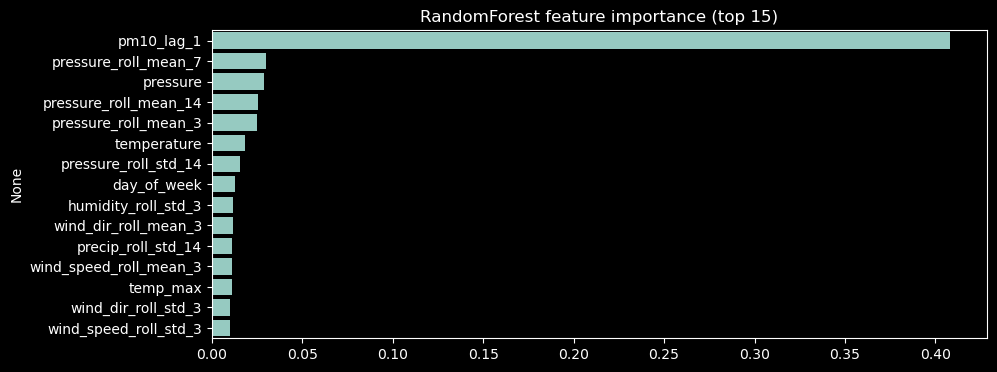

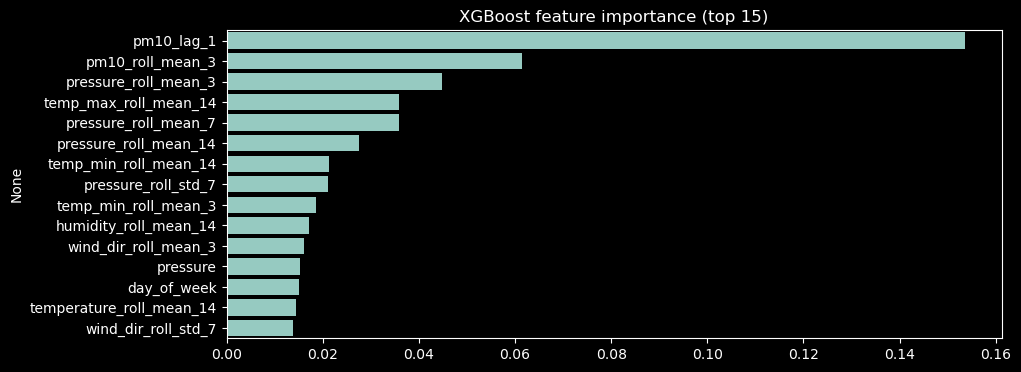

In [65]:
rf_importance = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)
xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 4))
sns.barplot(x=rf_importance.values, y=rf_importance.index)
plt.title("RandomForest feature importance (top 15)")
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(x=xgb_importance.values, y=xgb_importance.index)
plt.title("XGBoost feature importance (top 15)")
plt.show()

## 11. Sequence data for DL + walk-forward splits

In [68]:
data_scaled = data.copy()
data_scaled[feature_cols] = scaler.transform(data[feature_cols])

X_all = data_scaled[feature_cols].values
y_all = data_scaled[target_col].values
dates_all = data_scaled["date"].values

X_seq = []
y_seq = []
dates_seq = []
for i in range(SEQ_LEN, len(data_scaled)):
    X_seq.append(X_all[i - SEQ_LEN:i])
    y_seq.append(y_all[i])
    dates_seq.append(dates_all[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)
dates_seq = np.array(dates_seq)

test_start_date = data["date"].iloc[-TEST_DAYS]
train_mask = dates_seq < np.datetime64(test_start_date)

X_train_seq = X_seq[train_mask]
y_train_seq = y_seq[train_mask]
X_test_seq = X_seq[~train_mask]
y_test_seq = y_seq[~train_mask]
dates_train_seq = dates_seq[train_mask]
dates_test_seq = dates_seq[~train_mask]

tscv_seq = TimeSeriesSplit(n_splits=WALK_SPLITS)
seq_splits = list(tscv_seq.split(X_train_seq))

dl_results = {}
dl_histories = {}
dl_test_preds = {}

def rmse(y_true, y_pred):
    return root_mean_squared_error(y_true, y_pred)

def train_dl_model(name, build_fn):
    fold_rmses = []
    last_history = None
    last_model = None

    for fold, (tr_idx, val_idx) in enumerate(seq_splits, start=1):
        tf.keras.backend.clear_session()
        model = build_fn()
        model.compile(optimizer="adam", loss="mse")

        callbacks = [
            keras.callbacks.EarlyStopping(patience=PATIENCE, restore_best_weights=True),
        ]

        try:
            import tensorboard  # noqa: F401
            callbacks.append(
                keras.callbacks.TensorBoard(log_dir=os.path.join(LOG_DIR, name, f"fold_{fold}"))
            )
        except Exception:
            pass

        history = model.fit(
            X_train_seq[tr_idx],
            y_train_seq[tr_idx],
            validation_data=(X_train_seq[val_idx], y_train_seq[val_idx]),
            epochs=DL_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0,
            callbacks=callbacks,
        )

        val_pred = model.predict(X_train_seq[val_idx], verbose=0).ravel()
        fold_rmses.append(rmse(y_train_seq[val_idx], val_pred))

        if fold == len(seq_splits):
            last_history = history
            last_model = model

    dl_results[name] = float(np.mean(fold_rmses))
    dl_histories[name] = last_history
    dl_test_preds[name] = last_model.predict(X_test_seq, verbose=0).ravel()

## 12. SimpleRNN

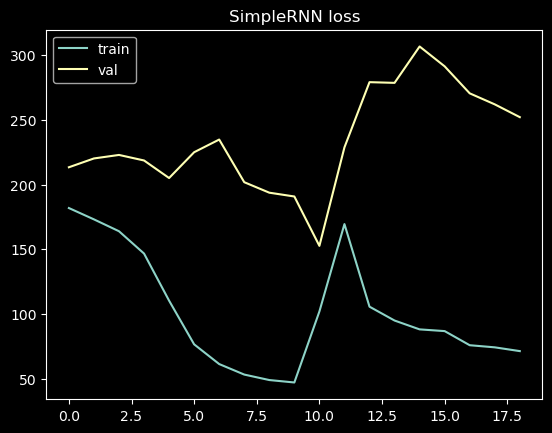

In [69]:
def build_rnn():
    return keras.Sequential([
        layers.Input(shape=(SEQ_LEN, X_train_seq.shape[2])),
        layers.SimpleRNN(32),
        layers.Dense(1),
    ])

train_dl_model("SimpleRNN", build_rnn)

history = dl_histories["SimpleRNN"]
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("SimpleRNN loss")
plt.legend()
plt.show()

## 13. GRU

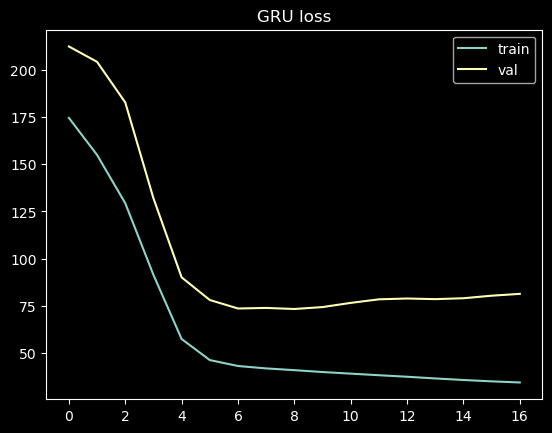

In [70]:
def build_gru():
    return keras.Sequential([
        layers.Input(shape=(SEQ_LEN, X_train_seq.shape[2])),
        layers.GRU(32),
        layers.Dense(1),
    ])

train_dl_model("GRU", build_gru)

history = dl_histories["GRU"]
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("GRU loss")
plt.legend()
plt.show()

## 14. LSTM

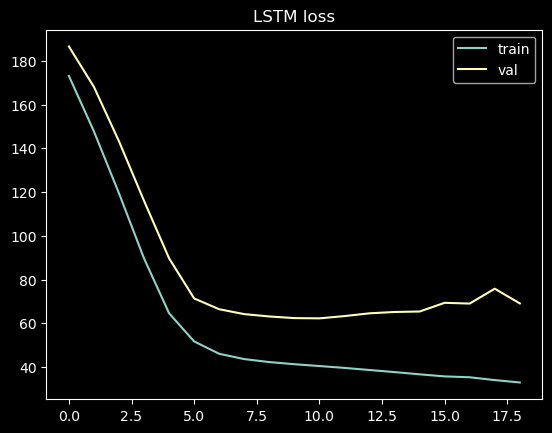

In [71]:
def build_lstm():
    return keras.Sequential([
        layers.Input(shape=(SEQ_LEN, X_train_seq.shape[2])),
        layers.LSTM(32),
        layers.Dense(1),
    ])

train_dl_model("LSTM", build_lstm)

history = dl_histories["LSTM"]
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("LSTM loss")
plt.legend()
plt.show()

## 15. 1D CNN

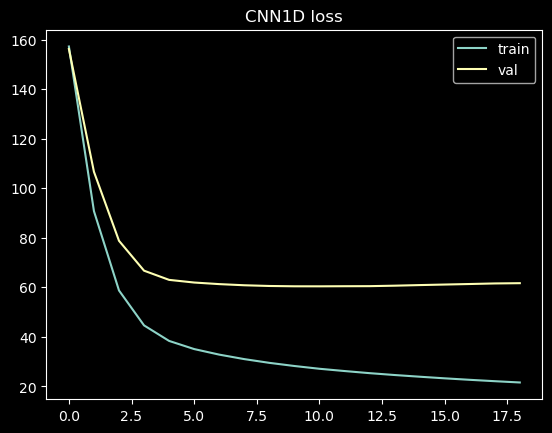

In [72]:
def build_cnn():
    return keras.Sequential([
        layers.Input(shape=(SEQ_LEN, X_train_seq.shape[2])),
        layers.Conv1D(32, kernel_size=3, activation="relu"),
        layers.GlobalMaxPooling1D(),
        layers.Dense(1),
    ])

train_dl_model("CNN1D", build_cnn)

history = dl_histories["CNN1D"]
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("CNN1D loss")
plt.legend()
plt.show()

## 16. TCN

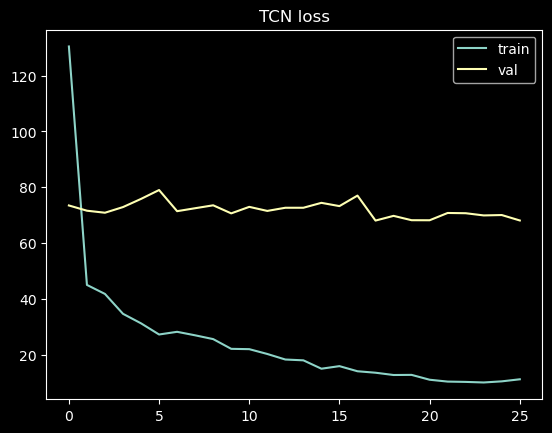

In [73]:
def build_tcn():
    return keras.Sequential([
        layers.Input(shape=(SEQ_LEN, X_train_seq.shape[2])),
        TCN(32, kernel_size=3, dilations=[1, 2, 4, 8], dropout_rate=0.1),
        layers.Dense(1),
    ])

train_dl_model("TCN", build_tcn)

history = dl_histories["TCN"]
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("TCN loss")
plt.legend()
plt.show()

## 17. Model comparison (RMSE)

In [74]:
dl_test_rmse = {name: rmse(y_test_seq, preds) for name, preds in dl_test_preds.items()}

all_rmse = pd.concat([
    pd.Series(ml_results, name="rmse"),
    pd.Series(dl_test_rmse, name="rmse"),
]).sort_values()

all_rmse

SVR                  4.411101
RandomForest         4.418042
LinearRegression     4.690480
XGBoost              4.712575
GRU                  5.916187
LSTM                 5.933716
CNN1D                6.395927
TCN                  6.644382
SimpleRNN           16.722105
Baseline            22.665258
Name: rmse, dtype: float64

## 18. Optuna tuning (50 trials per model)

In [75]:
tscv_tab = TimeSeriesSplit(n_splits=WALK_SPLITS)
X_train_np = X_train.values
y_train_np = y_train.values

tuned_scores = {}
best_params = {}

def cv_rmse_tab(model_builder):
    rmses = []
    for tr_idx, val_idx in tscv_tab.split(X_train_np):
        model = model_builder()
        model.fit(X_train_np[tr_idx], y_train_np[tr_idx])
        pred = model.predict(X_train_np[val_idx])
        rmses.append(rmse(y_train_np[val_idx], pred))
    return float(np.mean(rmses))

def objective_lin(trial):
    fit_intercept = trial.suggest_categorical("fit_intercept", [True, False])
    positive = trial.suggest_categorical("positive", [False, True])
    return cv_rmse_tab(lambda: make_pipeline(
        StandardScaler(),
        LinearRegression(fit_intercept=fit_intercept, positive=positive),
    ))

study_lin = optuna.create_study(direction="minimize")
study_lin.optimize(objective_lin, n_trials=OPTUNA_TRIALS)
tuned_scores["LinearRegression"] = study_lin.best_value
best_params["LinearRegression"] = study_lin.best_params

def objective_svr(trial):
    C = trial.suggest_float("C", 1e-2, 1e2, log=True)
    epsilon = trial.suggest_float("epsilon", 1e-3, 1.0, log=True)
    gamma = trial.suggest_float("gamma", 1e-4, 1.0, log=True)
    return cv_rmse_tab(lambda: make_pipeline(
        StandardScaler(),
        SVR(C=C, epsilon=epsilon, gamma=gamma),
    ))

study_svr = optuna.create_study(direction="minimize")
study_svr.optimize(objective_svr, n_trials=OPTUNA_TRIALS)
tuned_scores["SVR"] = study_svr.best_value
best_params["SVR"] = study_svr.best_params

def objective_rf(trial):
    n_estimators = trial.suggest_int("n_estimators", 200, 800, step=100)
    max_depth = trial.suggest_int("max_depth", 3, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)
    max_features = trial.suggest_float("max_features", 0.3, 1.0)
    return cv_rmse_tab(lambda: RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=SEED,
        n_jobs=-1,
    ))

study_rf = optuna.create_study(direction="minimize")
study_rf.optimize(objective_rf, n_trials=OPTUNA_TRIALS)
tuned_scores["RandomForest"] = study_rf.best_value
best_params["RandomForest"] = study_rf.best_params

def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    }
    return cv_rmse_tab(lambda: xgb.XGBRegressor(
        **params,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1,
    ))

study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(objective_xgb, n_trials=OPTUNA_TRIALS)
tuned_scores["XGBoost"] = study_xgb.best_value
best_params["XGBoost"] = study_xgb.best_params

def dl_cv_objective(trial, build_fn):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    rmses = []
    for fold, (tr_idx, val_idx) in enumerate(seq_splits, start=1):
        tf.keras.backend.clear_session()
        model = build_fn(trial)
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="mse")
        callbacks = [
            keras.callbacks.EarlyStopping(patience=PATIENCE, restore_best_weights=True),
            TFKerasPruningCallback(trial, "val_loss"),
        ]
        model.fit(
            X_train_seq[tr_idx],
            y_train_seq[tr_idx],
            validation_data=(X_train_seq[val_idx], y_train_seq[val_idx]),
            epochs=DL_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0,
            callbacks=callbacks,
        )
        val_pred = model.predict(X_train_seq[val_idx], verbose=0).ravel()
        rmses.append(rmse(y_train_seq[val_idx], val_pred))
    return float(np.mean(rmses))

def build_rnn_optuna(trial):
    units = trial.suggest_int("units", 16, 64, step=16)
    dropout = trial.suggest_float("dropout", 0.0, 0.3)
    return keras.Sequential([
        layers.Input(shape=(SEQ_LEN, X_train_seq.shape[2])),
        layers.SimpleRNN(units, dropout=dropout),
        layers.Dense(1),
    ])

study_rnn = optuna.create_study(direction="minimize")
study_rnn.optimize(lambda trial: dl_cv_objective(trial, build_rnn_optuna), n_trials=OPTUNA_TRIALS)
tuned_scores["SimpleRNN"] = study_rnn.best_value
best_params["SimpleRNN"] = study_rnn.best_params

def build_gru_optuna(trial):
    units = trial.suggest_int("units", 16, 64, step=16)
    dropout = trial.suggest_float("dropout", 0.0, 0.3)
    return keras.Sequential([
        layers.Input(shape=(SEQ_LEN, X_train_seq.shape[2])),
        layers.GRU(units, dropout=dropout),
        layers.Dense(1),
    ])

study_gru = optuna.create_study(direction="minimize")
study_gru.optimize(lambda trial: dl_cv_objective(trial, build_gru_optuna), n_trials=OPTUNA_TRIALS)
tuned_scores["GRU"] = study_gru.best_value
best_params["GRU"] = study_gru.best_params

def build_lstm_optuna(trial):
    units = trial.suggest_int("units", 16, 64, step=16)
    dropout = trial.suggest_float("dropout", 0.0, 0.3)
    return keras.Sequential([
        layers.Input(shape=(SEQ_LEN, X_train_seq.shape[2])),
        layers.LSTM(units, dropout=dropout),
        layers.Dense(1),
    ])

study_lstm = optuna.create_study(direction="minimize")
study_lstm.optimize(lambda trial: dl_cv_objective(trial, build_lstm_optuna), n_trials=OPTUNA_TRIALS)
tuned_scores["LSTM"] = study_lstm.best_value
best_params["LSTM"] = study_lstm.best_params

def build_cnn_optuna(trial):
    filters = trial.suggest_int("filters", 16, 64, step=16)
    kernel_size = trial.suggest_int("kernel_size", 2, 5)
    dropout = trial.suggest_float("dropout", 0.0, 0.3)
    return keras.Sequential([
        layers.Input(shape=(SEQ_LEN, X_train_seq.shape[2])),
        layers.Conv1D(filters, kernel_size=kernel_size, activation="relu"),
        layers.SpatialDropout1D(dropout),
        layers.GlobalMaxPooling1D(),
        layers.Dense(1),
    ])

study_cnn = optuna.create_study(direction="minimize")
study_cnn.optimize(lambda trial: dl_cv_objective(trial, build_cnn_optuna), n_trials=OPTUNA_TRIALS)
tuned_scores["CNN1D"] = study_cnn.best_value
best_params["CNN1D"] = study_cnn.best_params

def build_tcn_optuna(trial):
    filters = trial.suggest_int("filters", 16, 64, step=16)
    kernel_size = trial.suggest_int("kernel_size", 2, 5)
    dropout = trial.suggest_float("dropout", 0.0, 0.3)
    return keras.Sequential([
        layers.Input(shape=(SEQ_LEN, X_train_seq.shape[2])),
        TCN(filters, kernel_size=kernel_size, dilations=[1, 2, 4, 8], dropout_rate=dropout),
        layers.Dense(1),
    ])

study_tcn = optuna.create_study(direction="minimize")
study_tcn.optimize(lambda trial: dl_cv_objective(trial, build_tcn_optuna), n_trials=OPTUNA_TRIALS)
tuned_scores["TCN"] = study_tcn.best_value
best_params["TCN"] = study_tcn.best_params

pd.Series(tuned_scores).sort_values()

[I 2026-05-10 13:39:06,843] A new study created in memory with name: no-name-cd06dc37-6aab-44ee-9562-73cb42173a4d
[I 2026-05-10 13:39:06,858] Trial 0 finished with value: 13.573791618558433 and parameters: {'fit_intercept': False, 'positive': False}. Best is trial 0 with value: 13.573791618558433.
[I 2026-05-10 13:39:06,870] Trial 1 finished with value: 5.809482494633411 and parameters: {'fit_intercept': True, 'positive': True}. Best is trial 1 with value: 5.809482494633411.
[I 2026-05-10 13:39:06,880] Trial 2 finished with value: 13.573791618558433 and parameters: {'fit_intercept': False, 'positive': False}. Best is trial 1 with value: 5.809482494633411.
[I 2026-05-10 13:39:06,890] Trial 3 finished with value: 13.34589270976011 and parameters: {'fit_intercept': False, 'positive': True}. Best is trial 1 with value: 5.809482494633411.
[I 2026-05-10 13:39:06,901] Trial 4 finished with value: 13.573791618558433 and parameters: {'fit_intercept': False, 'positive': False}. Best is trial 1 w

RandomForest         5.784281
LinearRegression     5.809482
XGBoost              5.858929
SVR                  6.019400
TCN                  6.929443
CNN1D                8.795454
LSTM                 9.031675
GRU                  9.791738
SimpleRNN           10.948488
dtype: float64

## 19. Final training on best tuned models

In [76]:
ml_candidates = ["LinearRegression", "SVR", "RandomForest", "XGBoost"]
dl_candidates = ["SimpleRNN", "GRU", "LSTM", "CNN1D", "TCN"]

best_ml_name = min(
    {k: v for k, v in tuned_scores.items() if k in ml_candidates},
    key=lambda k: tuned_scores[k],
)
best_dl_name = min(
    {k: v for k, v in tuned_scores.items() if k in dl_candidates},
    key=lambda k: tuned_scores[k],
)

if best_ml_name == "LinearRegression":
    ml_model = make_pipeline(StandardScaler(), LinearRegression(**best_params[best_ml_name]))
elif best_ml_name == "SVR":
    ml_model = make_pipeline(StandardScaler(), SVR(**best_params[best_ml_name]))
elif best_ml_name == "RandomForest":
    ml_model = RandomForestRegressor(**best_params[best_ml_name], random_state=SEED, n_jobs=-1)
else:
    ml_model = xgb.XGBRegressor(
        **best_params[best_ml_name],
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1,
    )

ml_model.fit(X_train, y_train)
ml_best_pred = ml_model.predict(X_test)
ml_best_rmse = rmse(y_test, ml_best_pred)

best_dl_params = best_params[best_dl_name]
lr = best_dl_params.get("lr", 1e-3)

def build_best_dl():
    if best_dl_name == "SimpleRNN":
        return keras.Sequential([
            layers.Input(shape=(SEQ_LEN, X_train_seq.shape[2])),
            layers.SimpleRNN(best_dl_params.get("units", 32), dropout=best_dl_params.get("dropout", 0.0)),
            layers.Dense(1),
        ])
    if best_dl_name == "GRU":
        return keras.Sequential([
            layers.Input(shape=(SEQ_LEN, X_train_seq.shape[2])),
            layers.GRU(best_dl_params.get("units", 32), dropout=best_dl_params.get("dropout", 0.0)),
            layers.Dense(1),
        ])
    if best_dl_name == "LSTM":
        return keras.Sequential([
            layers.Input(shape=(SEQ_LEN, X_train_seq.shape[2])),
            layers.LSTM(best_dl_params.get("units", 32), dropout=best_dl_params.get("dropout", 0.0)),
            layers.Dense(1),
        ])
    if best_dl_name == "CNN1D":
        return keras.Sequential([
            layers.Input(shape=(SEQ_LEN, X_train_seq.shape[2])),
            layers.Conv1D(
                best_dl_params.get("filters", 32),
                kernel_size=best_dl_params.get("kernel_size", 3),
                activation="relu",
            ),
            layers.SpatialDropout1D(best_dl_params.get("dropout", 0.0)),
            layers.GlobalMaxPooling1D(),
            layers.Dense(1),
        ])
    return keras.Sequential([
        layers.Input(shape=(SEQ_LEN, X_train_seq.shape[2])),
        TCN(
            best_dl_params.get("filters", 32),
            kernel_size=best_dl_params.get("kernel_size", 3),
            dilations=[1, 2, 4, 8],
            dropout_rate=best_dl_params.get("dropout", 0.0),
        ),
        layers.Dense(1),
    ])

train_idx, val_idx = seq_splits[-1]
tf.keras.backend.clear_session()
dl_model = build_best_dl()
dl_model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="mse")
dl_history = dl_model.fit(
    X_train_seq[train_idx],
    y_train_seq[train_idx],
    validation_data=(X_train_seq[val_idx], y_train_seq[val_idx]),
    epochs=DL_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0,
    callbacks=[keras.callbacks.EarlyStopping(patience=PATIENCE, restore_best_weights=True)],
)
dl_best_pred = dl_model.predict(X_test_seq, verbose=0).ravel()
dl_best_rmse = rmse(y_test_seq, dl_best_pred)

if ml_best_rmse <= dl_best_rmse:
    best_overall_name = best_ml_name
    best_overall_pred = ml_best_pred
    best_overall_actual = y_test.values
    best_overall_dates = test["date"].values
    best_overall_rmse = ml_best_rmse
else:
    best_overall_name = best_dl_name
    best_overall_pred = dl_best_pred
    best_overall_actual = y_test_seq
    best_overall_dates = dates_test_seq
    best_overall_rmse = dl_best_rmse

best_overall_name, best_overall_rmse

('RandomForest', 4.356521860901037)

## 20. Diagnostics plots

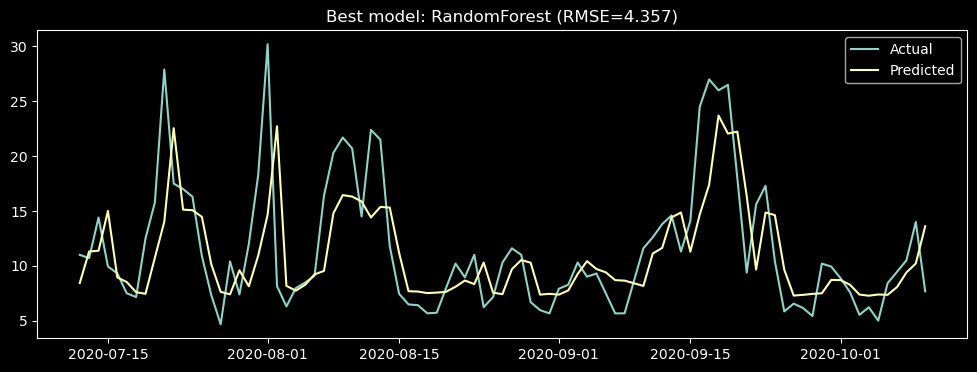

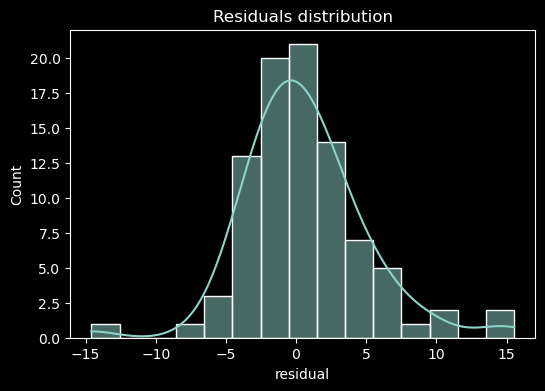

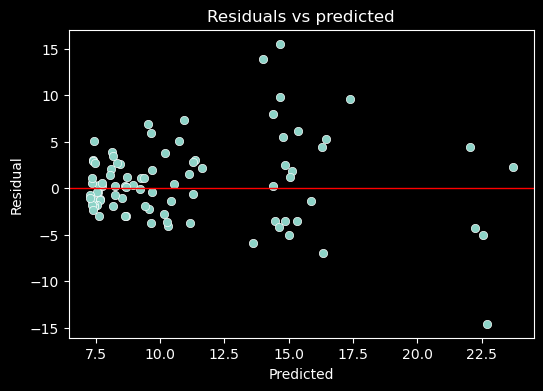

In [77]:
plot_df = pd.DataFrame({
    "date": pd.to_datetime(best_overall_dates),
    "actual": best_overall_actual,
    "pred": best_overall_pred,
})
plot_df["residual"] = plot_df["actual"] - plot_df["pred"]

plt.figure(figsize=(12, 4))
plt.plot(plot_df["date"], plot_df["actual"], label="Actual")
plt.plot(plot_df["date"], plot_df["pred"], label="Predicted")
plt.title(f"Best model: {best_overall_name} (RMSE={best_overall_rmse:.3f})")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(plot_df["residual"], kde=True)
plt.title("Residuals distribution")
plt.show()

plt.figure(figsize=(6, 4))
sns.scatterplot(x=plot_df["pred"], y=plot_df["residual"])
plt.axhline(0, color="red", linewidth=1)
plt.title("Residuals vs predicted")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.show()